# Data Preprocessing
---

In [2]:
!pip -q install pandas numpy matplotlib seaborn statsmodels scipy beautifulsoup4 tqdm PyPDF2 pdfplumber

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.optimize import linprog, milp, LinearConstraint, Bounds
from dataclasses import dataclass
import argparse
from pathlib import Path
import re
import glob
from bs4 import BeautifulSoup
from tqdm import tqdm
from PyPDF2 import PdfReader
import pdfplumber


In [2]:
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from component.data_transformer_html import generate_csvs_from_folder
from component.csv_combiner import combine_csvs_from_folder
from component.pdf_processor import process_all_pdfs
from component.optimization import (
    prepare_optimization_data,
    run_meal_optimization,
    run_meal_optimization_ilp,
    generate_item_breakdown,
    run_size_based_optimization,
    run_monthly_meal_optimization,
    run_proportional_monthly_optimization
)
from component.optimization_milk import (
    prepare_optimization_data_m,
    run_meal_optimization_m,
    run_meal_optimization_ilp_m,
    generate_item_breakdown_m,
    run_size_based_optimization_m,
    run_monthly_meal_optimization_m,
    run_proportional_monthly_optimization_m
)

### Data Transformer (HTML)

This pipeline processes structured HTML reports of school lunch and breakfast production data and converts them into clean CSV files for analysis.

- Reads all `.html` files from a specified folder.
- Extracts tables for each school using BeautifulSoup.
- Parses key metrics: planned, offered, served, discarded, and cost-related values.
- Automatically detects the reporting date from the content or file name.
- Saves parsed results as individual `.csv` files in the target directory.

In [ ]:
folder_path = "../data/FairfaxCounty/May 2025 Lunch production records/May 2025 Lunch production records"
output_dir = "../data/preprocessed-data/Lunch production"
generate_csvs_from_folder(folder_path, output_dir)

folder_path = "../data/FairfaxCounty/May 2025 Breakfast production records/May 2025 Breakfast production records"
output_dir = "../data/preprocessed-data/Breakfast production"
generate_csvs_from_folder(folder_path, output_dir)


### CSV Combiner (HTML)

- Collects all `.csv` files in an output folder.
- Merges them into one combined dataset.
- Optionally sorts by columns like `School_Name`, `Date`, and `Identifier`.
- Saves final merged CSVs for both **Breakfast** and **Lunch** datasets.

In [ ]:
# Breakfast
input_dir = '../data/preprocessed-data/Breakfast production'
output_file = '../data/preprocessed-data/breakfast_combined.csv'
sort_columns = ['School_Name', 'Date', 'Identifier']

combine_csvs_from_folder(input_dir, output_file, sort_columns)


In [ ]:
# Lunch
input_dir = '../data/preprocessed-data/Lunch production'
output_file = '../data/preprocessed-data/lunch_combined.csv'
sort_columns = ['School_Name', 'Date', 'Identifier']

combine_csvs_from_folder(input_dir, output_file, sort_columns)

### PDF Processing

In [ ]:
# Define the input and output paths relative to the notebook's location
pdf_folder = "../data/FairfaxCounty/Item Sales Reports - Mar May 2025/Item Sales Reports - Mar May 2025"
output_file = "../data/preprocessed-data/sales.csv"

# Call the function to process all PDFs and generate the combined sales.csv
process_all_pdfs(pdf_folder, output_file)

---
# Data Cleaning and EDA
---

In [3]:
# Set plot style
sns.set(style="whitegrid")

### EDA of Breakfast Data: breakfast_combined

In [4]:
# Load your dataset
dfb = pd.read_csv('../data/preprocessed-data/breakfast_combined.csv')
dfb['School_Name'] = dfb['School_Name'].str.lower()
dfb.head()

,School_Name,Date,Identifier,Name,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,Served_Reimbursable,Served_Non-Reimbursable,Served_Total,Discarded_Total,Discarded_Cost,Subtotal_Cost,Left_Over_Total,Left_Over_Percent_of_Offered,Left_Over_Cost,Production_Cost_Total
0,aldrin elementary,5/01/2025,10041,Mini Maple Pancakes (Package),57,0,57,59,56,0,56,$21.84,0,0.00%,$0.00,$21.84,3,5.08%,$1.17,$23.01
1,aldrin elementary,5/01/2025,20001,1% White Milk (Each),33,0,33,37,34,0,34,$12.24,0,0.00%,$0.00,$12.24,3,8.11%,$1.08,$13.32
2,aldrin elementary,5/01/2025,20017,Orange (6 Slices per 1/2 cup),51,0,51,55,53,0,53,$18.02,0,0.00%,$0.00,$18.02,2,3.64%,$0.68,$18.70
3,aldrin elementary,5/01/2025,20038,Fat Free White Milk (Each),11,0,11,15,13,0,13,$4.29,0,0.00%,$0.00,$4.29,2,13.33%,$0.66,$4.95
4,aldrin elementary,5/01/2025,30003,Honey Cheerios Cereal (Each),10,0,10,10,7,0,7,$4.13,0,0.00%,$0.00,$4.13,3,30.00%,$1.77,$5.90


In [5]:
# Show basic info
print("Shape of dataset:", dfb.shape)
print("\nData types:\n", dfb.dtypes)

Shape of dataset: (55646, 20)

Data types:
 School_Name                     object
Date                            object
Identifier                      object
Name                            object
Planned_Reimbursable             int64
Planned_Non-Reimbursable         int64
Planned_Total                    int64
Offered_Reimbursable             int64
Offered_Non-Reimbursable         int64
Offered_Total                    int64
Served_Reimbursable              int64
Served_Non-Reimbursable         object
Served_Total                     int64
Discarded_Total                 object
Discarded_Cost                  object
Subtotal_Cost                   object
Left_Over_Total                  int64
Left_Over_Percent_of_Offered    object
Left_Over_Cost                  object
Production_Cost_Total           object
dtype: object


In [6]:
# show statistics
dfb.describe()

,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,Served_Reimbursable,Served_Total,Left_Over_Total
count,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000,55646.000000
mean,33.435431,0.081300,33.516731,45.235812,35.404432,0.507817,35.912249,0.129282,9.195450
std,63.312415,1.042007,63.355922,68.060557,58.877480,3.289844,59.028820,1.021627,21.275619
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,2.000000,10.000000,5.000000,0.000000,6.000000,0.000000,0.000000
50%,14.000000,0.000000,14.000000,24.000000,16.000000,0.000000,17.000000,0.000000,3.000000
75%,40.000000,0.000000,40.000000,51.000000,40.000000,0.000000,41.000000,0.000000,10.000000
max,4561.000000,63.000000,4561.000000,2245.000000,2216.000000,165.000000,2216.000000,53.000000,985.000000


In [7]:
# Check for missing values
print("\nMissing values:\n", dfb.isnull().sum())


Missing values:
 School_Name                     0
Date                            0
Identifier                      0
Name                            0
Planned_Reimbursable            0
Planned_Non-Reimbursable        0
Planned_Total                   0
Offered_Reimbursable            0
Offered_Non-Reimbursable        0
Offered_Total                   0
Served_Reimbursable             0
Served_Non-Reimbursable         0
Served_Total                    0
Discarded_Total                 0
Discarded_Cost                  0
Subtotal_Cost                   0
Left_Over_Total                 0
Left_Over_Percent_of_Offered    0
Left_Over_Cost                  0
Production_Cost_Total           0
dtype: int64


In [8]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfb.duplicated().sum())


Number of duplicate rows: 0


In [9]:
# overview look at food names
food_cat = dfb.groupby('Name')['Planned_Total'].sum()

summary_b = food_cat.sort_values(ascending=False)
sumb_10 = summary_b.head(10
)
print(sumb_10)

Name
Apple Juice (Each)                                     453973
Orange Tangerine Juice (Each)                          248470
1% White Milk (Each)                                   211190
Mini Maple Pancakes (Package)                          140160
Red Delicious Apple (Each - serving)                    89769
Honey Cheerios Cereal (Each)                            76478
Cinnamon Toast Crunch Cereal, 25% Less Sugar (Each)     71307
Cinnamon Chex Cereal (Each)                             67403
Fat Free White Milk (Each)                              64173
Blueberry Chex Cereal (Each)                            59862
Name: Planned_Total, dtype: int64


### EDA of Lunch Data: lunch_combined

In [10]:
# Load your dataset
dfl = pd.read_csv('../data/preprocessed-data/lunch_combined.csv')
dfl['School_Name'] = dfl['School_Name'].str.lower()
dfl.head()

C:\Users\kaoji\AppData\Local\Temp\ipykernel_23856\3363551025.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfl = pd.read_csv('../data/preprocessed-data/lunch_combined.csv')


,School_Name,Date,Identifier,Name,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,Served_Reimbursable,Served_Non-Reimbursable,Served_Total,Discarded_Total,Discarded_Cost,Subtotal_Cost,Left_Over_Total,Left_Over_Percent_of_Offered,Left_Over_Cost,Production_Cost_Total
0,aldrin elementary,5/01/2025,10044,Soft Pretzel (1 pretzel),15,0,15,31,27,0,27,$5.94,0,0.00%,$0.00,$5.94,4,12.90%,$0.88,$6.82
1,aldrin elementary,5/01/2025,10062,Corn (1/4 cup (thawed)),92,0,92,155,152,0,152,$16.72,0,0.00%,$0.00,$16.72,3,1.94%,$0.33,$17.05
2,aldrin elementary,5/01/2025,20001,1% White Milk (Each),44,0,44,120,43,0,43,$15.48,0,0.00%,$0.00,$15.48,77,64.17%,$27.72,$43.20
3,aldrin elementary,5/01/2025,20002,Fat Free Chocolate Milk (Each),133,0,133,155,131,0,131,$45.85,0,0.00%,$0.00,$45.85,24,15.48%,$8.40,$54.25
4,aldrin elementary,5/01/2025,20016,String Cheese (Each),2,0,2,5,2,0,2,$0.44,0,0.00%,$0.00,$0.44,3,60.00%,$0.66,$1.10


In [11]:
# Show basic info
print("Shape of dataset:", dfl.shape)
print("\nData types:\n", dfl.dtypes)

Shape of dataset: (136111, 20)

Data types:
 School_Name                     object
Date                            object
Identifier                      object
Name                            object
Planned_Reimbursable             int64
Planned_Non-Reimbursable         int64
Planned_Total                    int64
Offered_Reimbursable             int64
Offered_Non-Reimbursable         int64
Offered_Total                    int64
Served_Reimbursable              int64
Served_Non-Reimbursable         object
Served_Total                     int64
Discarded_Total                 object
Discarded_Cost                  object
Subtotal_Cost                   object
Left_Over_Total                  int64
Left_Over_Percent_of_Offered    object
Left_Over_Cost                  object
Production_Cost_Total           object
dtype: object


In [12]:
# show statistics
dfl.describe()

,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,Served_Reimbursable,Served_Total,Left_Over_Total
count,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000,136111.000000
mean,60.195950,0.631389,60.827339,87.493884,70.779614,2.375583,73.155197,0.548001,13.793103
std,203.746777,9.022324,204.262536,177.571425,162.788814,14.983064,163.544555,3.501302,43.741154
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,13.000000,6.000000,0.000000,9.000000,0.000000,0.000000
50%,20.000000,0.000000,20.000000,42.000000,30.000000,0.000000,32.000000,0.000000,1.000000
75%,70.000000,0.000000,70.000000,100.000000,87.000000,0.000000,90.000000,0.000000,10.000000
max,54100.000000,500.000000,54100.000000,40030.000000,39957.000000,630.000000,39957.000000,525.000000,1286.000000


In [13]:
# Check for missing values
print("\nMissing values:\n", dfl.isnull().sum())


Missing values:
 School_Name                     0
Date                            0
Identifier                      0
Name                            0
Planned_Reimbursable            0
Planned_Non-Reimbursable        0
Planned_Total                   0
Offered_Reimbursable            0
Offered_Non-Reimbursable        0
Offered_Total                   0
Served_Reimbursable             0
Served_Non-Reimbursable         0
Served_Total                    0
Discarded_Total                 0
Discarded_Cost                  0
Subtotal_Cost                   0
Left_Over_Total                 0
Left_Over_Percent_of_Offered    0
Left_Over_Cost                  0
Production_Cost_Total           0
dtype: int64


In [14]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfl.duplicated().sum())


Number of duplicate rows: 0


In [15]:
# overview look at food names
food_cat = dfl.groupby('Name')['Planned_Total'].sum()

summary_l = food_cat.sort_values(ascending=False)
suml_10 = summary_l.head(10
)
print(suml_10)

Name
Fat Free Chocolate Milk (Each)          966354
Lettuce Blend Salad Mix (1/2 cup)       622525
Ketchup Packet (Packet)                 600672
Ranch Dressing (1 ounce)                361148
PB&J Power Pack (Power Packs)           337854
1% White Milk (Each)                    249208
Manager's Vegetable Choice (1/4 cup)    235047
Cheese Pizza (Slice)                    198151
Mayonnaise Packet (Packet)              193858
Chicken Tenders (3 tenders)             174341
Name: Planned_Total, dtype: int64


### EDA of Sales

In [16]:
# Load your dataset
dfs = pd.read_csv('../data/preprocessed-data/sales.csv')
dfs.head()

,time_of_day,school_code,school_name,date,item,description,total,free_meals,reduced_price_meals,full_price_meals,adults,alac_student,alac_adult,earned_student,earned_adult,earned_alac_student,earned_alac_adult,adj_alac,adj_meal
0,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,1146,CEREAL MEAL,10,2,0,8,0,0,0,0,0,0,0,0,0
1,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,1170,MINI PANCAKES,32,2,0,30,0,0,0,0,0,0,0,0,0
2,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,1310,ALC BREAKFAST ENTREE,8,0,0,0,0,8,0,0,0,0,0,0,0
3,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,1405,EGG & CHEESE ON BISCUIT,2,0,0,2,0,0,0,0,0,0,0,0,0
4,breakfast,17,COLVIN_RUN_ELEMENTARY,5/1/25,151,CEREAL/ NO MILK,9,0,0,0,0,9,0,0,0,0,0,0,0


In [17]:
# Show basic info
print("Shape of dataset:", dfs.shape)
print("\nData types:\n", dfs.dtypes)

Shape of dataset: (224536, 19)

Data types:
 time_of_day            object
school_code             int64
school_name            object
date                   object
item                    int64
description            object
total                   int64
free_meals              int64
reduced_price_meals     int64
full_price_meals        int64
adults                  int64
alac_student            int64
alac_adult              int64
earned_student          int64
earned_adult            int64
earned_alac_student     int64
earned_alac_adult       int64
adj_alac                int64
adj_meal                int64
dtype: object


In [18]:
# show statistics
dfs.describe()

,school_code,item,total,free_meals,reduced_price_meals,full_price_meals,adults,alac_student,alac_adult,earned_student,earned_adult,earned_alac_student,earned_alac_adult,adj_alac,adj_meal
count,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.0
mean,221.613398,1245.693274,40.621615,15.044964,1.497666,11.708799,0.137043,12.225830,0.096283,0.001038,0.303288,0.003643,0.000334,0.000013,0.0
std,133.682146,909.230796,69.212535,40.143932,5.621533,27.997202,2.062739,41.665041,0.954267,0.052410,1.239649,0.189640,0.023019,0.003655,0.0
min,17.000000,1.000000,0.000000,-3.000000,-1.000000,-18.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,103.000000,717.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,206.000000,1136.000000,14.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,334.000000,1310.000000,46.000000,11.000000,1.000000,11.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
max,501.000000,3501.000000,955.000000,942.000000,801.000000,649.000000,267.000000,947.000000,43.000000,9.000000,37.000000,25.000000,5.000000,1.000000,0.0


In [19]:
# Check for missing values
print("\nMissing values:\n", dfs.isnull().sum())


Missing values:
 time_of_day            0
school_code            0
school_name            0
date                   0
item                   0
description            0
total                  0
free_meals             0
reduced_price_meals    0
full_price_meals       0
adults                 0
alac_student           0
alac_adult             0
earned_student         0
earned_adult           0
earned_alac_student    0
earned_alac_adult      0
adj_alac               0
adj_meal               0
dtype: int64


In [20]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfs.duplicated().sum())


Number of duplicate rows: 0


In [21]:
# Convert your datetime column
dfs['date'] = pd.to_datetime(dfs['date']) 

# Set datetime as index
dfs.set_index('date', inplace=True)

# Sort by date
dfs = dfs.sort_index()


C:\Users\kaoji\AppData\Local\Temp\ipykernel_23856\1267965289.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dfs['date'] = pd.to_datetime(dfs['date'])


In [22]:
# Check date range and frequency
print("Date Range:", dfs.index.min(), "to", dfs.index.max())
print("Frequency (inferred):", pd.infer_freq(dfs.index))

Date Range: 2025-03-03 00:00:00 to 2025-05-30 00:00:00
Frequency (inferred): None


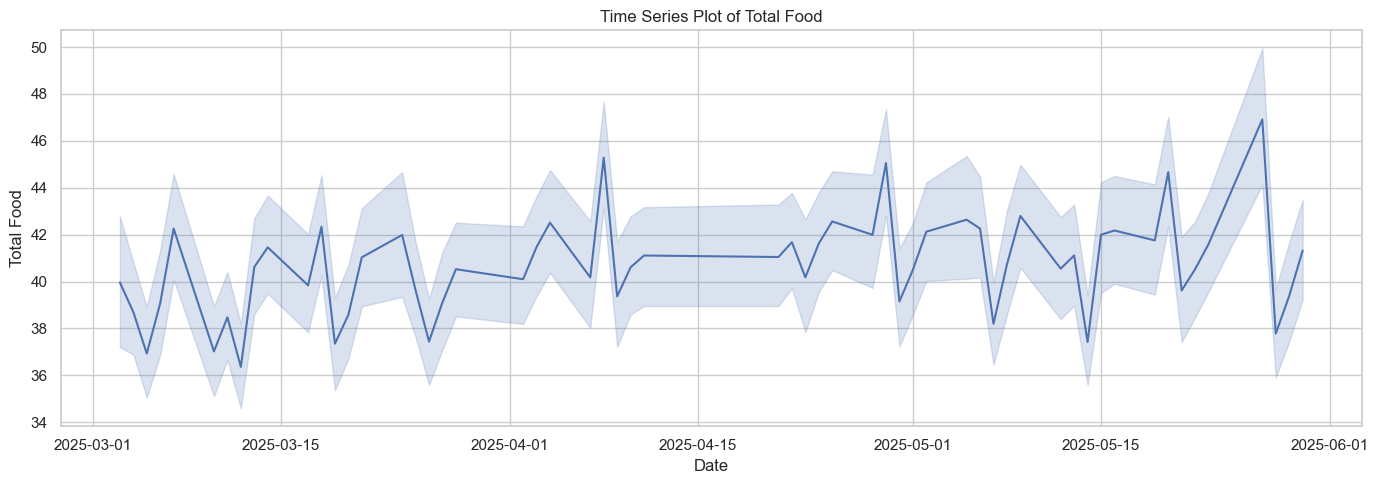

In [23]:
# Plot full time series for a numeric column
plt.figure(figsize=(14, 5))
sns.lineplot(data=dfs, x=dfs.index, y='total')
plt.title("Time Series Plot of Total Food")
plt.xlabel("Date")
plt.ylabel("Total Food")
plt.tight_layout()
plt.show()

---
# Food Popularity
---

In [24]:
# assigning a different variable name to the dataframes
sales = dfs
breakfast = dfb
lunch = dfl

In [25]:
# converting column names to lowercase
sales.columns = sales.columns.str.lower()
breakfast.columns = breakfast.columns.str.lower()
lunch.columns = lunch.columns.str.lower()

In [26]:
# converting date columns into datatime objects
breakfast['date'] = pd.to_datetime(breakfast['date'])
lunch['date'] = pd.to_datetime(lunch['date'])

In [27]:
# define function to clean numeric columns
def clean_numeric(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)                                # forcing to string
                .str.replace(r"[\$,%, ]", "", regex=True)   # removing $%, and spaces
                .replace("nan", "0")                        # replacing nan with 0
                .astype(float)                              # converting to float
            )
    return df

In [28]:
#
num_cols = [
    "served_non-reimbursable", "discarded_total", "discarded_cost",
    "subtotal_cost", "left_over_percent_of_offered", "left_over_cost",
    "left_over_total", "production_cost_total"
]
breakfast = clean_numeric(breakfast, num_cols)
lunch = clean_numeric(lunch, num_cols)

In [29]:
# ------- Finding the popular items -------

# From sales
popular_sales = (
    sales.groupby(["time_of_day", "description"])["total"]
    .sum()
    .reset_index()
    .sort_values(["time_of_day", "total"], ascending=[True, False])
)

# From breakfast (by served)
popular_breakfast = (
    breakfast.groupby("name")["served_reimbursable"]
    .sum()
    .reset_index()
    .sort_values("served_reimbursable", ascending=False)
)

# From lunch (by served)
popular_lunch = (
    lunch.groupby("name")["served_reimbursable"]
    .sum()
    .reset_index()
    .sort_values("served_reimbursable", ascending=False)
)

In [30]:
# --- Least discarded (lower is better) ---
if "discarded_total" in breakfast.columns:
    popular_breakfast_low_discarded = (
        breakfast.groupby("name")["discarded_total"]
        .sum()
        .reset_index()
        .sort_values("discarded_total", ascending=True)
    )
else:
    popular_breakfast_low_discarded = None

if "discarded_total" in lunch.columns:
    popular_lunch_low_discarded = (
        lunch.groupby("name")["discarded_total"]
        .sum()
        .reset_index()
        .sort_values("discarded_total", ascending=True)
    )
else:
    popular_lunch_low_discarded = None

In [31]:
print("Top 10 Breakfast Items (by served_total):")
print(popular_breakfast.head(10))

print("\nTop 10 Lunch Items (by served_total):")
print(popular_lunch.head(10))

if popular_breakfast_low_discarded is not None:
    print("\nTop 10 Breakfast Items (least discarded_total):")
    print(popular_breakfast_low_discarded.head(10))

if popular_lunch_low_discarded is not None:
    print("\nTop 10 Lunch Items (least discarded_total):")
    print(popular_lunch_low_discarded.head(10))


Top 10 Breakfast Items (by served_total):
                                                  name  served_reimbursable
7                                   Apple Juice (Each)               422347
99                       Orange Tangerine Juice (Each)               227110
83                       Mini Maple Pancakes (Package)               196086
2                                 1% White Milk (Each)               189429
19                                       Bagel (Bagel)                92610
71                        Honey Cheerios Cereal (Each)                71032
57                                 Cream Cheese (Each)                70942
110               Red Delicious Apple (Each - serving)                69694
55   Cinnamon Toast Crunch Cereal, 25% Less Sugar (...                63964
54                         Cinnamon Chex Cereal (Each)                59553

Top 10 Lunch Items (by served_total):
                                     name  served_reimbursable
169        Fat Free 

In [32]:
# ------- Finding the actual amount of food consumed (served minus discarded) -------

# Breakfast
breakfast_net_consumption = (
    breakfast.groupby("name")
    .agg({
        'served_reimbursable': 'sum',
        'discarded_total': 'sum'
    })
    .reset_index()
)

# Calculating net consumption
breakfast_net_consumption['net_consumption'] = (
    breakfast_net_consumption['served_reimbursable'] - breakfast_net_consumption['discarded_total']
)

# Sorting by net consumption (higher is better)
breakfast_net_consumption = breakfast_net_consumption.sort_values('net_consumption', ascending=False)

# Lunch
lunch_net_consumption = (
    lunch.groupby("name")
    .agg({
        'served_reimbursable': 'sum',
        'discarded_total': 'sum'
    })
    .reset_index()
)

# Calculate new consumption
lunch_net_consumption['net_consumption'] = (
    lunch_net_consumption['served_reimbursable'] - lunch_net_consumption['discarded_total']
)

# Sorting by net consumption (higher is better)
lunch_net_consumption = lunch_net_consumption.sort_values('net_consumption', ascending=False)

In [33]:
# --- Display Net Consumption Results ---
print("=== NET CONSUMPTION POPULARITY RANKINGS ===")

print("\nTop 15 Breakfast Items (by Net Consumption):")
print("=" * 90)
breakfast_display = breakfast_net_consumption[['name', 'net_consumption', 'served_reimbursable', 'discarded_total']].head(15)
breakfast_display.columns = ['Item Name', 'Net Consumption', 'Total Served', 'Total Discarded']
print(breakfast_display)

print("\nTop 15 Lunch Items (by Net Consumption):")
print("=" * 90)
lunch_display = lunch_net_consumption[['name', 'net_consumption', 'served_reimbursable', 'discarded_total']].head(15)
lunch_display.columns = ['Item Name', 'Net Consumption', 'Total Served', 'Total Discarded']
print(lunch_display)

=== NET CONSUMPTION POPULARITY RANKINGS ===

Top 15 Breakfast Items (by Net Consumption):
                                             Item Name  Net Consumption  \
7                                   Apple Juice (Each)        422247.16   
99                       Orange Tangerine Juice (Each)        227001.49   
83                       Mini Maple Pancakes (Package)        195252.97   
2                                 1% White Milk (Each)        188965.25   
19                                       Bagel (Bagel)         91235.15   
57                                 Cream Cheese (Each)         70882.48   
71                        Honey Cheerios Cereal (Each)         70799.31   
110               Red Delicious Apple (Each - serving)         69423.46   
55   Cinnamon Toast Crunch Cereal, 25% Less Sugar (...         63588.42   
54                         Cinnamon Chex Cereal (Each)         59150.37   
29                        Blueberry Chex Cereal (Each)         50500.01   
64        

In [34]:
# ---------- Finding the items with the highest leftover rate ----------

# Breakfast
breakfast_leftover_rate = (
    breakfast.groupby("name")
    .agg({
        'left_over_total': 'sum',
        'offered_reimbursable': 'sum'
    })
    .reset_index()
)

# Calculate leftover rate (percentage)
breakfast_leftover_rate['leftover_rate'] = (
    breakfast_leftover_rate['left_over_total'] / 
    breakfast_leftover_rate['offered_reimbursable'].replace(0, 1)
) * 100

# Sorting by leftover rate (higher is worse)
breakfast_leftover_rate = breakfast_leftover_rate.sort_values('leftover_rate', ascending=False)

# Lunch
lunch_leftover_rate = (
    lunch.groupby("name")
    .agg({
        'left_over_total': 'sum',
        'offered_reimbursable': 'sum'
    })
    .reset_index()
)

# Calculate leftover rate (percentage)
lunch_leftover_rate['leftover_rate'] = (
    lunch_leftover_rate['left_over_total'] / 
    lunch_leftover_rate['offered_reimbursable'].replace(0, 1)
) * 100

# Sorting by leftover rate (higher is worse)
lunch_leftover_rate = lunch_leftover_rate.sort_values('leftover_rate', ascending=False)

In [35]:
# --- Display Leftover Rate Results ---
print("=== LEFTOVER RATE RANKINGS ===")

print("\nTop 15 Breakfast Items (Highest Leftover Rate - Most Waste):")
print("=" * 100)
breakfast_display = breakfast_leftover_rate[['name', 'leftover_rate', 'left_over_total', 'offered_reimbursable']].head(15)
breakfast_display.columns = ['Item Name', 'Leftover Rate (%)', 'Total Left Over', 'Total Offered']
breakfast_display['Leftover Rate (%)'] = breakfast_display['Leftover Rate (%)'].round(2)
print(breakfast_display)

print("\nTop 15 Lunch Items (Highest Leftover Rate - Most Waste):")
print("=" * 100)
lunch_display = lunch_leftover_rate[['name', 'leftover_rate', 'left_over_total', 'offered_reimbursable']].head(15)
lunch_display.columns = ['Item Name', 'Leftover Rate (%)', 'Total Left Over', 'Total Offered']
lunch_display['Leftover Rate (%)'] = lunch_display['Leftover Rate (%)'].round(2)
print(lunch_display)

=== LEFTOVER RATE RANKINGS ===

Top 15 Breakfast Items (Highest Leftover Rate - Most Waste):
                                             Item Name  Leftover Rate (%)  \
62                      Fat Free Chocolate Milk (Each)              98.83   
37   Cereal, Cinnamon Toasters, Malt-O-Meal, IW (Su...              60.26   
64                          Fat Free White Milk (Each)              53.49   
43            Cherry Flavored Dried Cranberries (Each)              53.12   
63        Fat Free Unflavored Shelf-Stable Milk (Each)              52.70   
80   Milk, Lactose Free,  Fat Free, Shelf-Stable (E...              51.28   
96            Orange Flavored Dried Cranberries (Each)              50.00   
132   Watermelon Flavored Dried Cranberries (2 Eaches)              48.05   
17                        Assorted Cereal (Cereal Cup)              47.13   
101             Patty, Chicken, Breaded, WG (2 strips)              46.88   
66                       Frozen, Blueberries (1/2 cup)      

In [36]:
# Calculate overall statistics
print("\n=== OVERALL LEFTOVER STATISTICS ===")
breakfast_total_leftover = breakfast['left_over_total'].sum()
breakfast_total_offered = breakfast['offered_reimbursable'].sum()
breakfast_overall_rate = (breakfast_total_leftover / breakfast_total_offered) * 100

lunch_total_leftover = lunch['left_over_total'].sum()
lunch_total_offered = lunch['offered_reimbursable'].sum()
lunch_overall_rate = (lunch_total_leftover / lunch_total_offered) * 100

print(f"Breakfast Overall Leftover Rate: {breakfast_overall_rate:.2f}%")
print(f"  Total Left Over: {breakfast_total_leftover:,.0f}")
print(f"  Total Offered: {breakfast_total_offered:,.0f}")

print(f"\nLunch Overall Leftover Rate: {lunch_overall_rate:.2f}%")
print(f"  Total Left Over: {lunch_total_leftover:,.0f}")
print(f"  Total Offered: {lunch_total_offered:,.0f}")

print(f"\nCombined Overall Leftover Rate: {((breakfast_total_leftover + lunch_total_leftover) / (breakfast_total_offered + lunch_total_offered)) * 100:.2f}%")



=== OVERALL LEFTOVER STATISTICS ===
Breakfast Overall Leftover Rate: 20.33%
  Total Left Over: 511,690
  Total Offered: 2,517,192

Lunch Overall Leftover Rate: 15.76%
  Total Left Over: 1,877,393
  Total Offered: 11,908,880

Combined Overall Leftover Rate: 16.56%


---
# Time Series Analysis


---
# Optimization
---

In [37]:
# Define file paths
breakfast_file = '../data/preprocessed-data/breakfast_combined.csv'
lunch_file = '../data/preprocessed-data/lunch_combined.csv'
student_counts_file = '../data/preprocessed-data/2022-2025 Fairfax County School Student Count.csv'

# Prepare all data needed for the optimization models
opt_data = prepare_optimization_data(breakfast_file, lunch_file, student_counts_file)

--- Preparing Optimization Data ---
Data preparation complete.


In [38]:
if opt_data:
    # Set up parameters for this specific scenario
    total_budget = 139144760
    budget_per_school = total_budget / len(opt_data['schools'])
    school_budgets = {s: budget_per_school for s in opt_data['schools']}
    waste_penalty = [0.50, 1.00]

    daily_bounds = []
    for school in opt_data['schools']:
        for i in range(len(opt_data['meal_types'])):
            daily_bounds.append((opt_data['demand'][school][i] * 0.90, opt_data['demand'][school][i] * 1.10))

    # Run the optimization and generate the item breakdown
    results_df = run_meal_optimization(
        opt_data['schools'], opt_data['meal_types'], opt_data['meal_costs'], 
        opt_data['demand'], school_budgets, total_budget, waste_penalty, daily_bounds
    )
    generate_item_breakdown(results_df, opt_data['dfb'], opt_data['dfl'], '../data/school_food_item_optimization.csv')


--- Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $261136.18

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 290 units (Demand: 322, Prod. Bounds: 290-354)
    Lunch: 1317 units (Demand: 1463, Prod. Bounds: 1317-1609)
    School Total Cost: $657.94 (Budget: $732340.84)

  annandale high:
    Breakfast: 2396 units (Demand: 2662, Prod. Bounds: 2396-2928)
    Lunch: 6617 units (Demand: 7353, Prod. Bounds: 6617-8088)
    School Total Cost: $3696.09 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 1029 units (Demand: 1144, Prod. Bounds: 1029-1258)
    Lunch: 2219 units (Demand: 2466, Prod. Bounds: 2219-2712)
    School Total Cost: $1333.23 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 181 units (Demand: 202, Prod. Bounds: 181-221)
    Lunch: 871 units (Demand: 968, Prod. Bounds: 871-1064)
    School Total Cost: $430.65 (Budget: $732340.84)

  baileys lower e

In [39]:
if opt_data and opt_data['all_school_lists']:
    run_size_based_optimization(
        opt_data['schools'], opt_data['meal_types'], opt_data['meal_costs'],
        opt_data['demand'], {s: (139144760 / len(opt_data['schools'])) for s in opt_data['schools']}, 
        36362814, [0.50, 1.00], opt_data['all_school_lists']
    )

--- Starting Size-Based Optimization ---
Categorized 190 schools based on your lists.
Production bounds have been set based on custom school sizes.

--- Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $266084.80

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 273 units (Demand: 322, Prod. Bounds: 273-370)
    Lunch: 1243 units (Demand: 1463, Prod. Bounds: 1243-1682)
    School Total Cost: $620.68 (Budget: $732340.84)

  annandale high:
    Breakfast: 2582 units (Demand: 2662, Prod. Bounds: 2582-2742)
    Lunch: 7132 units (Demand: 7353, Prod. Bounds: 7132-7573)
    School Total Cost: $3983.55 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 1029 units (Demand: 1144, Prod. Bounds: 1029-1258)
    Lunch: 2219 units (Demand: 2466, Prod. Bounds: 2219-2712)
    School Total Cost: $1333.23 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 171 units (Demand: 202, Prod

c:\Users\kaoji\OneDrive\Documents\Grad School\6501-Capstone\fall-2025-group2\src\component\optimization.py:345: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfl = pd.read_csv('../data/preprocessed-data/lunch_combined.csv')


In [40]:
# Runs the monthly forecast model
if opt_data:
    # Set up parameters specific to the monthly scenario
    SCHOOL_DAYS_PER_MONTH = 20
    waste_penalty = [0.50, 1.00]
    
    monthly_demand = {s: [d[0] * SCHOOL_DAYS_PER_MONTH, d[1] * SCHOOL_DAYS_PER_MONTH] for s, d in opt_data['demand'].items()}
    
    monthly_bounds = []
    for school in opt_data['schools']:
        for i, meal_type in enumerate(opt_data['meal_types']):
            monthly_bounds.append((monthly_demand[school][i] * 0.85, monthly_demand[school][i] * 1.10))
    
    # Call the monthly optimization function
    run_monthly_meal_optimization(
        opt_data['schools'],
        opt_data['meal_types'],
        opt_data['meal_costs'],
        monthly_demand,
        waste_penalty,
        monthly_bounds
    )


--- Starting Monthly Optimization (No Budget Constraint) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful! Minimum Monthly Cost: $4,932,572.29

Optimal Monthly Meal Production Plan (Sample):

  aldrin elementary:
    Breakfast: 5,478 units (Monthly Demand: 6,445, Prod. Bounds: 5,478-7,089)
    Lunch: 24,876 units (Monthly Demand: 29,267, Prod. Bounds: 24,876-32,193)

  annandale high:
    Breakfast: 45,262 units (Monthly Demand: 53,250, Prod. Bounds: 45,262-58,574)
    Lunch: 124,997 units (Monthly Demand: 147,056, Prod. Bounds: 124,997-161,761)

  annandale terrace elementary:
    Breakfast: 19,454 units (Monthly Demand: 22,888, Prod. Bounds: 19,454-25,176)
    Lunch: 41,917 units (Monthly Demand: 49,314, Prod. Bounds: 41,917-54,245)

  armstrong elementary:
    Breakfast: 3,426 units (Monthly Demand: 4,031, Prod. Bounds: 3,426-4,434)
    Lunch: 16,453 units (Monthly Demand: 19,357, Prod. Bounds: 16,453-21,292)

  baileys lower elementary:
    Breakfast: 24,396 u

In [41]:
# Runs the daily Integer Linear Programming (ILP) model
if opt_data:
    # Set up the same daily parameters as the first model
    total_budget = 139144760
    budget_per_school = total_budget / len(opt_data['schools'])
    school_budgets = {s: budget_per_school for s in opt_data['schools']}
    waste_penalty = [0.50, 1.00]
    
    daily_bounds = []
    for school in opt_data['schools']:
        for i in range(len(opt_data['meal_types'])):
            daily_bounds.append((opt_data['demand'][school][i] * 0.90, opt_data['demand'][school][i] * 1.10))

    # Call the ILP function with all the required arguments
    ilp_results_df = run_meal_optimization_ilp(
        opt_data['schools'], opt_data['meal_types'], opt_data['meal_costs'], 
        opt_data['demand'], school_budgets, total_budget, waste_penalty, daily_bounds
    )
    
    # Generate a separate breakdown file for the ILP results
    generate_item_breakdown(ilp_results_df, opt_data['dfb'], opt_data['dfl'], '../data/school_food_item_optimization_ilp.csv')


--- Integer Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $261225.87

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 291 units (Demand: 322, Prod. Bounds: 290-354)
    Lunch: 1317 units (Demand: 1463, Prod. Bounds: 1317-1609)
    School Total Cost: $658.36 (Budget: $732340.84)

  annandale high:
    Breakfast: 2397 units (Demand: 2662, Prod. Bounds: 2396-2928)
    Lunch: 6618 units (Demand: 7353, Prod. Bounds: 6617-8088)
    School Total Cost: $3696.91 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 1030 units (Demand: 1144, Prod. Bounds: 1029-1258)
    Lunch: 2220 units (Demand: 2466, Prod. Bounds: 2219-2712)
    School Total Cost: $1334.06 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 182 units (Demand: 202, Prod. Bounds: 181-221)
    Lunch: 872 units (Demand: 968, Prod. Bounds: 871-1064)
    School Total Cost: $431.47 (Budget: $732340.84)

  baileys

In [42]:
# Runs the proportional budget monthly optimization
if opt_data:
    run_proportional_monthly_optimization(opt_data)


Proportional Budget Monthly Optimization (LP)

--- Allocating Budget Based on Student Population ---
Total budget of $139,144,760.00 allocated proportionally.

--- Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $4932572.29

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 5478 units (Demand: 6445, Prod. Bounds: 5478-7089)
    Lunch: 24876 units (Demand: 29267, Prod. Bounds: 24876-32193)
    School Total Cost: $12427.67 (Budget: $350842.99)

  annandale high:
    Breakfast: 45262 units (Demand: 53250, Prod. Bounds: 45262-58574)
    Lunch: 124997 units (Demand: 147056, Prod. Bounds: 124997-161761)
    School Total Cost: $69820.52 (Budget: $1584712.58)

  annandale terrace elementary:
    Breakfast: 19454 units (Demand: 22888, Prod. Bounds: 19454-25176)
    Lunch: 41917 units (Demand: 49314, Prod. Bounds: 41917-54245)
    School Total Cost: $25191.53 (Budget: $689847.72)

  armstrong elementar

# Milk Optimization

In [43]:
# add in nutrition file
nutrition = pd.read_csv("../data/preprocessed-data/fcps_nutrition_values.csv")
nutrition.rename(columns={'Food_Name': 'name'}, inplace=True)

# add column to dfb/dfl
dfb = dfb.merge(nutrition, on='name', how='left')
dfl = dfl.merge(nutrition, on='name', how='left')

In [44]:
# create milk files
milk_b = dfb[dfb['Sub-Category'] == 'Milk']
milk_l = dfl[dfl['Sub-Category'] == 'Milk']

In [45]:
# save files as csv
milk_b.to_csv('../data/preprocessed-data/milk_b.csv', index=False)
milk_l.to_csv('../data/preprocessed-data/milk_l.csv', index=False)

In [46]:
# Define file paths
breakfast_milk_file = '../data/preprocessed-data/milk_b.csv'
lunch_milk_file = '../data/preprocessed-data/milk_b.csv'
student_counts_file = '../data/preprocessed-data/2022-2025 Fairfax County School Student Count.csv'

# Prepare all data needed for the optimization models
opt_data_milk = prepare_optimization_data_m(breakfast_milk_file, lunch_milk_file, student_counts_file)

--- Preparing Optimization Data ---
Data preparation complete.


In [47]:
if opt_data_milk:
    # Set up parameters for this specific scenario
    total_budget = 139144760
    budget_per_school = total_budget / len(opt_data_milk['schools'])
    school_budgets = {s: budget_per_school for s in opt_data_milk['schools']}
    waste_penalty = [0.50, 1.00]

    daily_bounds = []
    for school in opt_data_milk['schools']:
        for i in range(len(opt_data_milk['meal_types'])):
            daily_bounds.append((opt_data_milk['demand'][school][i] * 0.90, opt_data_milk['demand'][school][i] * 1.10))

    # Run the optimization and generate the item breakdown
    results_df = run_meal_optimization_m(
        opt_data_milk['schools'], opt_data_milk['meal_types'], opt_data_milk['meal_costs'], 
        opt_data_milk['demand'], school_budgets, total_budget, waste_penalty, daily_bounds
    )
    generate_item_breakdown_m(results_df, milk_b, milk_l, '../data/school_milk_optimization.csv')


--- Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $14102.47

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 42 units (Demand: 47, Prod. Bounds: 42-52)
    Lunch: 42 units (Demand: 47, Prod. Bounds: 42-52)
    School Total Cost: $48.56 (Budget: $732340.84)

  annandale high:
    Breakfast: 132 units (Demand: 148, Prod. Bounds: 132-162)
    Lunch: 132 units (Demand: 148, Prod. Bounds: 132-162)
    School Total Cost: $152.63 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 129 units (Demand: 144, Prod. Bounds: 129-158)
    Lunch: 129 units (Demand: 144, Prod. Bounds: 129-158)
    School Total Cost: $149.16 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 32 units (Demand: 36, Prod. Bounds: 32-39)
    Lunch: 32 units (Demand: 36, Prod. Bounds: 32-39)
    School Total Cost: $37.00 (Budget: $732340.84)

  baileys lower elementary:
    Breakfast: 243 units (Deman

In [48]:
if opt_data_milk and opt_data_milk['all_school_lists']:
    run_size_based_optimization_m(
        opt_data_milk['schools'], opt_data_milk['meal_types'], opt_data_milk['meal_costs'],
        opt_data_milk['demand'], {s: (139144760 / len(opt_data_milk['schools'])) for s in opt_data_milk['schools']}, 
        36362814, [0.50, 1.00], opt_data_milk['all_school_lists']
    )

--- Starting Size-Based Optimization ---
Categorized 190 schools based on your lists.
Production bounds have been set based on custom school sizes.

--- Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $14109.32

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 40 units (Demand: 47, Prod. Bounds: 40-54)
    Lunch: 40 units (Demand: 47, Prod. Bounds: 40-54)
    School Total Cost: $46.25 (Budget: $732340.84)

  annandale high:
    Breakfast: 143 units (Demand: 148, Prod. Bounds: 143-152)
    Lunch: 143 units (Demand: 148, Prod. Bounds: 143-152)
    School Total Cost: $165.35 (Budget: $732340.84)

  annandale terrace elementary:
    Breakfast: 129 units (Demand: 144, Prod. Bounds: 129-158)
    Lunch: 129 units (Demand: 144, Prod. Bounds: 129-158)
    School Total Cost: $149.16 (Budget: $732340.84)

  armstrong elementary:
    Breakfast: 30 units (Demand: 36, Prod. Bounds: 30-41)
    Lunch: 30 uni

c:\Users\kaoji\OneDrive\Documents\Grad School\6501-Capstone\fall-2025-group2\src\component\optimization_milk.py:345: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfl = pd.read_csv('../data/preprocessed-data/lunch_combined.csv')


In [49]:
# Runs the monthly forecast model
if opt_data_milk:
    # Set up parameters specific to the monthly scenario
    SCHOOL_DAYS_PER_MONTH = 20
    waste_penalty = [0.50, 1.00]
    
    monthly_demand = {s: [d[0] * SCHOOL_DAYS_PER_MONTH, d[1] * SCHOOL_DAYS_PER_MONTH] for s, d in opt_data_milk['demand'].items()}
    
    monthly_bounds = []
    for school in opt_data_milk['schools']:
        for i, meal_type in enumerate(opt_data_milk['meal_types']):
            monthly_bounds.append((monthly_demand[school][i] * 0.85, monthly_demand[school][i] * 1.10))
    
    # Call the monthly optimization function
    run_monthly_meal_optimization_m(
        opt_data_milk['schools'],
        opt_data_milk['meal_types'],
        opt_data_milk['meal_costs'],
        monthly_demand,
        waste_penalty,
        monthly_bounds
    )


--- Starting Monthly Optimization (No Budget Constraint) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful! Minimum Monthly Cost: $266,380.03

Optimal Monthly Meal Production Plan (Sample):

  aldrin elementary:
    Breakfast: 807 units (Monthly Demand: 950, Prod. Bounds: 807-1,044)
    Lunch: 807 units (Monthly Demand: 950, Prod. Bounds: 807-1,044)

  annandale high:
    Breakfast: 2,509 units (Monthly Demand: 2,952, Prod. Bounds: 2,509-3,247)
    Lunch: 2,509 units (Monthly Demand: 2,952, Prod. Bounds: 2,509-3,247)

  annandale terrace elementary:
    Breakfast: 2,452 units (Monthly Demand: 2,885, Prod. Bounds: 2,452-3,173)
    Lunch: 2,452 units (Monthly Demand: 2,885, Prod. Bounds: 2,452-3,173)

  armstrong elementary:
    Breakfast: 607 units (Monthly Demand: 714, Prod. Bounds: 607-785)
    Lunch: 607 units (Monthly Demand: 714, Prod. Bounds: 607-785)

  baileys lower elementary:
    Breakfast: 4,596 units (Monthly Demand: 5,408, Prod. Bounds: 4,596-5,948)
   

In [50]:
# Runs the daily Integer Linear Programming (ILP) model
if opt_data_milk:
    # Set up the same daily parameters as the first model
    total_budget = 139144760
    budget_per_school = total_budget / len(opt_data_milk['schools'])
    school_budgets = {s: budget_per_school for s in opt_data_milk['schools']}
    waste_penalty = [0, 0]
    
    daily_bounds = []
    for school in opt_data_milk['schools']:
        for i in range(len(opt_data_milk['meal_types'])):
            daily_bounds.append((0, None))

    # Call the ILP function with all the required arguments
    ilp_results_df = run_meal_optimization_ilp_m(
        opt_data_milk['schools'], opt_data_milk['meal_types'], opt_data_milk['meal_costs'], 
        opt_data_milk['demand'], school_budgets, total_budget, waste_penalty, daily_bounds
    )
    
    # Generate a separate breakdown file for the ILP results
    generate_item_breakdown_m(ilp_results_df, milk_b, milk_l, '../data/school_milk_optimization_ilp.csv')


--- Integer Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization failed: (HiGHS Status 2: Model error)
Skipping item breakdown: No optimization results.


In [51]:
# Runs the proportional budget monthly optimization
if opt_data:
    run_proportional_monthly_optimization(opt_data)


Proportional Budget Monthly Optimization (LP)

--- Allocating Budget Based on Student Population ---
Total budget of $139,144,760.00 allocated proportionally.

--- Linear Programming Optimization (Daily) ---
Objective: Minimize Cost + Waste Penalty

Optimization Successful!
Minimum Cost: $4932572.29

Optimal Meal Production Plan:

  aldrin elementary:
    Breakfast: 5478 units (Demand: 6445, Prod. Bounds: 5478-7089)
    Lunch: 24876 units (Demand: 29267, Prod. Bounds: 24876-32193)
    School Total Cost: $12427.67 (Budget: $350842.99)

  annandale high:
    Breakfast: 45262 units (Demand: 53250, Prod. Bounds: 45262-58574)
    Lunch: 124997 units (Demand: 147056, Prod. Bounds: 124997-161761)
    School Total Cost: $69820.52 (Budget: $1584712.58)

  annandale terrace elementary:
    Breakfast: 19454 units (Demand: 22888, Prod. Bounds: 19454-25176)
    Lunch: 41917 units (Demand: 49314, Prod. Bounds: 41917-54245)
    School Total Cost: $25191.53 (Budget: $689847.72)

  armstrong elementar